# 👑 DropQueen
## Notebook 1: Exploratory Data Analysis (EDA)
**Project:** AI-Powered Product Demand & Sales Forecasting Engine for TikTok Shop & Amazon  
**Author:** Chastity Lewis  
**Course:** CISC 610 — DevOps and MLOps | Mercy University | Spring 2026  
**Datasets:** Amazon Beauty Products Reviews 5-Core + Viral Social Media Trends

---

### 📌 Notebook Goals
1. Load and inspect both datasets
2. Understand shape, columns, and data types
3. Check for missing values and duplicates
4. Explore rating distributions and product trends
5. Filter TikTok data from social media dataset
6. Engineer key features for demand forecasting
7. Save clean datasets for model training

---

## Step 1: Install & Import Libraries

In [1]:
!pip install pandas numpy matplotlib scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.style.use('seaborn-v0_8-whitegrid')
GOLD   = '#F59E0B'
BLACK  = '#1F1F1F'
WHITE  = '#FFFFFF'
DARK   = '#111111'
COLORS = ['#F59E0B', '#FCD34D', '#B45309', '#FDE68A', '#D97706']

print('✅ Libraries loaded!')

✅ Libraries loaded!


## Step 2: Load Amazon Beauty Dataset

In [3]:
from google.colab import files
import io

print('📂 Upload ratings_Beauty.csv')
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Amazon 5-core format has no header
df_amazon = pd.read_csv(
    io.BytesIO(uploaded[filename]),
    names=['user_id', 'product_id', 'rating', 'timestamp'],
    header=None
)

print(f'\n✅ Amazon Beauty dataset loaded!')
print(f'📊 Shape: {df_amazon.shape[0]:,} rows × {df_amazon.shape[1]} columns')
df_amazon.head()

📂 Upload ratings_Beauty.csv


Saving ratings_Beauty.csv to ratings_Beauty.csv

✅ Amazon Beauty dataset loaded!
📊 Shape: 2,023,071 rows × 4 columns


,user_id,product_id,rating,timestamp
0,UserId,ProductId,Rating,Timestamp
1,A39HTATAQ9V7YF,0205616461,5.0,1369699200
2,A3JM6GV9MNOF9X,0558925278,3.0,1355443200
3,A1Z513UWSAAO0F,0558925278,5.0,1404691200
4,A1WMRR494NWEWV,0733001998,4.0,1382572800


## Step 3: Load TikTok / Social Media Dataset

In [4]:
print('📂 Upload Viral_Social_Media_Trends.csv')
uploaded2 = files.upload()
filename2 = list(uploaded2.keys())[0]

df_social = pd.read_csv(io.BytesIO(uploaded2[filename2]))

print(f'\n✅ Social Media Trends dataset loaded!')
print(f'📊 Shape: {df_social.shape[0]:,} rows × {df_social.shape[1]} columns')
print(f'\nColumns: {df_social.columns.tolist()}')
df_social.head()

📂 Upload Viral_Social_Media_Trends.csv


Saving Viral_Social_Media_Trends.csv to Viral_Social_Media_Trends.csv

✅ Social Media Trends dataset loaded!
📊 Shape: 5,000 rows × 10 columns

Columns: ['Post_ID', 'Platform', 'Hashtag', 'Content_Type', 'Region', 'Views', 'Likes', 'Shares', 'Comments', 'Engagement_Level']


,Post_ID,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level
0,Post_1,TikTok,#Challenge,Video,UK,4163464,339431,53135,19346,High
1,Post_2,Instagram,#Education,Shorts,India,4155940,215240,65860,27239,Medium
2,Post_3,Twitter,#Challenge,Video,Brazil,3666211,327143,39423,36223,Medium
3,Post_4,YouTube,#Education,Shorts,Australia,917951,127125,11687,36806,Low
4,Post_5,TikTok,#Dance,Post,Brazil,64866,171361,69581,6376,Medium


## Step 4: Explore Amazon Beauty Dataset

In [5]:
print('📋 Amazon Beauty Dataset Info:')
print(f'  Rows:            {df_amazon.shape[0]:,}')
print(f'  Columns:         {df_amazon.shape[1]}')
print(f'  Unique Products: {df_amazon["product_id"].nunique():,}')
print(f'  Unique Users:    {df_amazon["user_id"].nunique():,}')
print(f'\nData Types:')
print(df_amazon.dtypes)
print(f'\nDescriptive Statistics:')
df_amazon.describe()

📋 Amazon Beauty Dataset Info:
  Rows:            2,023,071
  Columns:         4
  Unique Products: 249,275
  Unique Users:    1,210,272

Data Types:
user_id       object
product_id    object
rating        object
timestamp     object
dtype: object

Descriptive Statistics:


,user_id,product_id,rating,timestamp
count,2023071,2023071,2023071.00,2023071
unique,1210272,249275,11.00,7848
top,A3KEZLJ59C1JVH,B001MA0QY2,5.00,1380672000
freq,389,7533,1165521.00,5499


In [6]:
# Check missing values
print('❓ Missing Values:')
missing = df_amazon.isnull().sum()
print(missing)
print(f'\n🔁 Duplicate rows: {df_amazon.duplicated().sum():,}')

❓ Missing Values:
user_id       0
product_id    0
rating        0
timestamp     0
dtype: int64

🔁 Duplicate rows: 0


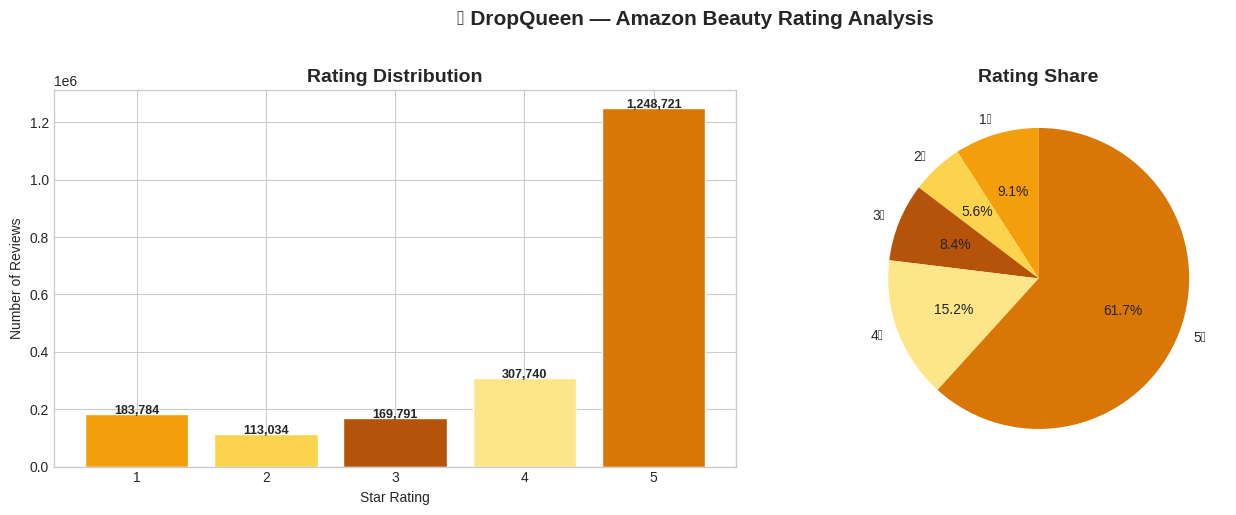

✅ Saved eda_01_ratings.png


In [10]:
# Convert 'rating' column to numeric, coercing errors, and drop rows with NaN ratings
df_amazon['rating'] = pd.to_numeric(df_amazon['rating'], errors='coerce')
df_amazon.dropna(subset=['rating'], inplace=True)

# Rating distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of ratings
rating_counts = df_amazon['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values,
            color=COLORS, edgecolor='white')
for i, (rating, count) in enumerate(rating_counts.items()):
    axes[0].text(rating, count + 1000, f'{count:,}',
                ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Rating Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_xticks([1, 2, 3, 4, 5])

# Pie chart
axes[1].pie(rating_counts.values, labels=[f'{int(r)}★' for r in rating_counts.index],
            autopct='%1.1f%%', colors=COLORS, startangle=90)
axes[1].set_title('Rating Share', fontsize=14, fontweight='bold')

plt.suptitle('👑 DropQueen — Amazon Beauty Rating Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_01_ratings.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved eda_01_ratings.png')

## Step 5: Engineer Timestamp Features

In [11]:
# Convert Unix timestamp to datetime
df_amazon['date'] = pd.to_datetime(df_amazon['timestamp'], unit='s')
df_amazon['year']  = df_amazon['date'].dt.year
df_amazon['month'] = df_amazon['date'].dt.month
df_amazon['week']  = df_amazon['date'].dt.isocalendar().week.astype(int)
df_amazon['day_of_week'] = df_amazon['date'].dt.dayofweek

print('✅ Timestamp features engineered!')
print(f'\nDate range:')
print(f'  Earliest review: {df_amazon["date"].min().strftime("%B %d, %Y")}')
print(f'  Latest review:   {df_amazon["date"].max().strftime("%B %d, %Y")}')
print(f'  Years covered:   {df_amazon["year"].nunique()} years')
df_amazon[['user_id', 'product_id', 'rating', 'date', 'year', 'month']].head()

✅ Timestamp features engineered!

Date range:
  Earliest review: October 19, 1998
  Latest review:   July 23, 2014
  Years covered:   17 years


,user_id,product_id,rating,date,year,month
1,A39HTATAQ9V7YF,0205616461,5.00,2013-05-28,2013,5
2,A3JM6GV9MNOF9X,0558925278,3.00,2012-12-14,2012,12
3,A1Z513UWSAAO0F,0558925278,5.00,2014-07-07,2014,7
4,A1WMRR494NWEWV,0733001998,4.00,2013-10-24,2013,10
5,A3IAAVS479H7M7,0737104473,1.00,2010-05-19,2010,5


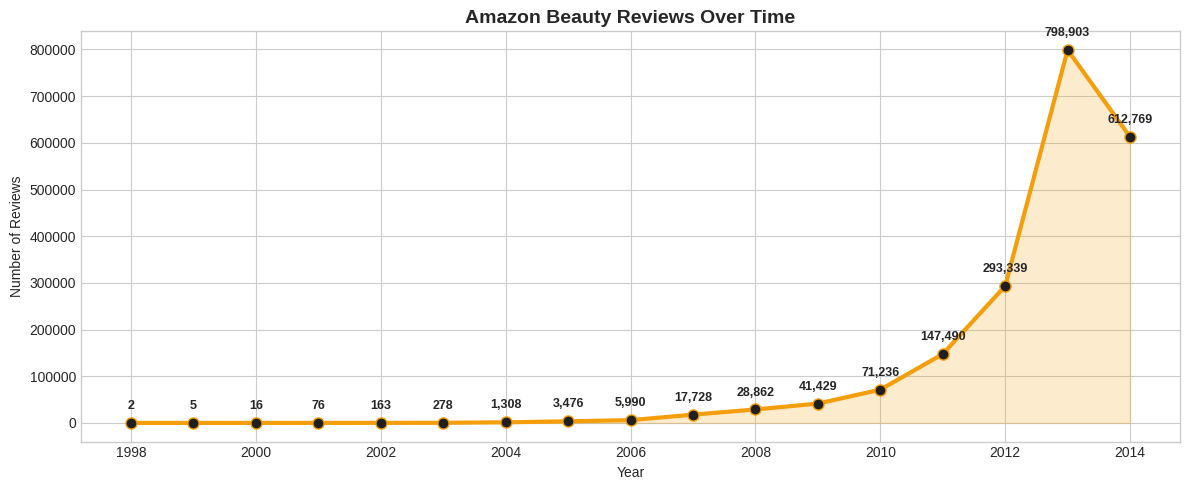

✅ Saved eda_02_reviews_over_time.png


In [12]:
# Reviews over time
reviews_by_year = df_amazon.groupby('year').size()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(reviews_by_year.index, reviews_by_year.values,
        color=GOLD, linewidth=3, marker='o', markersize=8, markerfacecolor=BLACK)
ax.fill_between(reviews_by_year.index, reviews_by_year.values,
                alpha=0.2, color=GOLD)
ax.set_title('Amazon Beauty Reviews Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Reviews')

for year, count in reviews_by_year.items():
    ax.annotate(f'{count:,}', (year, count),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_02_reviews_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved eda_02_reviews_over_time.png')

## Step 6: Top Products Analysis

In [13]:
# Most reviewed products
top_products = df_amazon.groupby('product_id').agg(
    review_count=('rating', 'count'),
    avg_rating=('rating', 'mean'),
    rating_std=('rating', 'std')
).reset_index().sort_values('review_count', ascending=False)

print('🏆 Top 10 Most Reviewed Beauty Products:')
print(top_products.head(10).to_string(index=False))

🏆 Top 10 Most Reviewed Beauty Products:
product_id  review_count  avg_rating  rating_std
B001MA0QY2          7533        4.32        1.19
B0009V1YR8          2869        3.57        1.70
B0043OYFKU          2477        4.31        1.08
B0000YUXI0          2143        4.41        1.17
B003V265QW          2088        4.37        1.10
B000ZMBSPE          2041        4.42        1.05
B003BQ6QXK          1918        4.63        0.87
B004OHQR1Q          1885        4.47        0.98
B00121UVU0          1838        4.54        0.97
B000FS05VG          1589        4.16        1.24


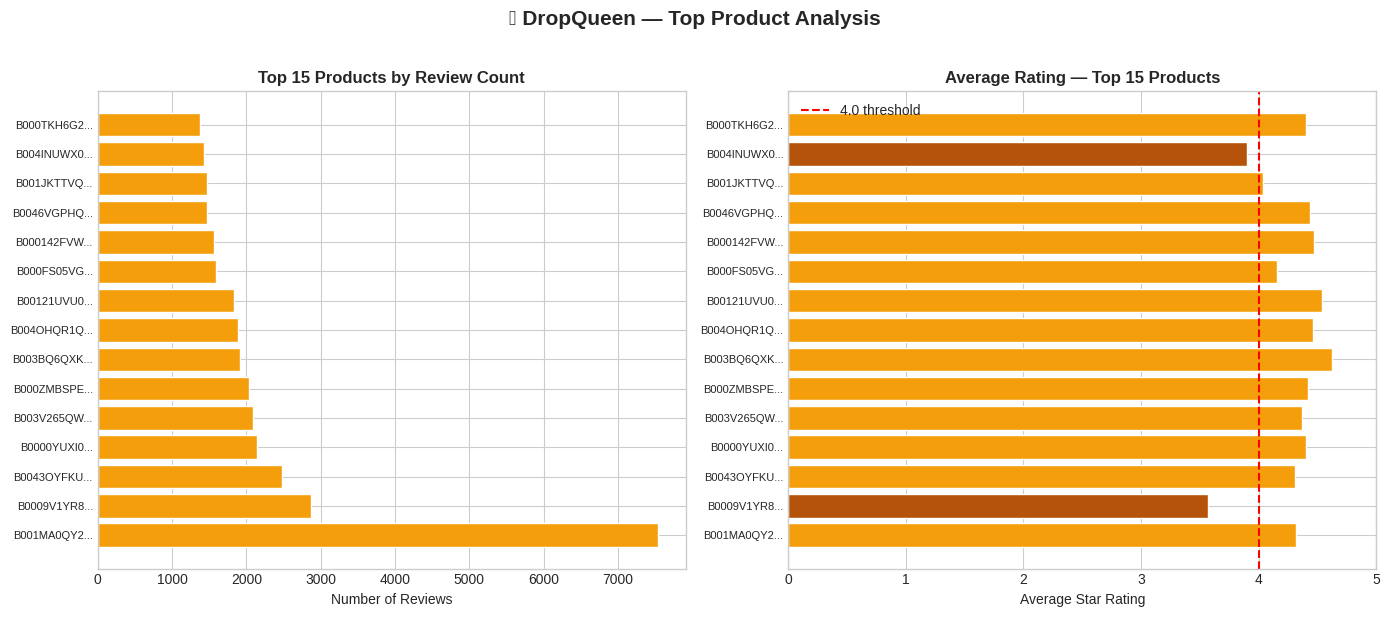

✅ Saved eda_03_top_products.png


In [14]:
# Visualize top 15 products by review count
top15 = top_products.head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Review count
axes[0].barh(range(len(top15)), top15['review_count'].values,
             color=GOLD, edgecolor='white')
axes[0].set_yticks(range(len(top15)))
axes[0].set_yticklabels([p[:12] + '...' for p in top15['product_id']], fontsize=8)
axes[0].set_title('Top 15 Products by Review Count', fontweight='bold')
axes[0].set_xlabel('Number of Reviews')

# Average rating
colors_rating = [GOLD if r >= 4.0 else '#B45309' for r in top15['avg_rating']]
axes[1].barh(range(len(top15)), top15['avg_rating'].values,
             color=colors_rating, edgecolor='white')
axes[1].set_yticks(range(len(top15)))
axes[1].set_yticklabels([p[:12] + '...' for p in top15['product_id']], fontsize=8)
axes[1].axvline(4.0, color='red', linestyle='--', linewidth=1.5, label='4.0 threshold')
axes[1].set_title('Average Rating — Top 15 Products', fontweight='bold')
axes[1].set_xlabel('Average Star Rating')
axes[1].set_xlim(0, 5)
axes[1].legend()

plt.suptitle('👑 DropQueen — Top Product Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_03_top_products.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved eda_03_top_products.png')

## Step 7: Demand Signal Engineering
> **Demand Signal** = weekly review count per product.  
> A spike in reviews = spike in purchases = demand surge.

In [19]:
# Engineer weekly demand signal — optimized for large dataset
weekly_demand = df_amazon.groupby(['product_id', 'year', 'week']).agg(
    weekly_reviews=('rating', 'count'),
    avg_weekly_rating=('rating', 'mean')
).reset_index()

# Simpler spike flag — no groupby transform (faster)
overall_threshold = weekly_demand['weekly_reviews'].quantile(0.80)
weekly_demand['demand_spike'] = (weekly_demand['weekly_reviews'] >= overall_threshold).astype(int)

print(f'✅ Weekly demand signal engineered!')
print(f'   Total weekly records: {len(weekly_demand):,}')
print(f'   Demand spike rate:    {weekly_demand["demand_spike"].mean()*100:.1f}%')
print(f'\nSample weekly demand data:')
weekly_demand.head(10)

✅ Weekly demand signal engineered!
   Total weekly records: 1,504,357
   Demand spike rate:    100.0%

Sample weekly demand data:


,product_id,year,week,weekly_reviews,avg_weekly_rating,demand_spike
0,0205616461,2013,22,1,5.00,1
1,0558925278,2012,50,1,3.00,1
2,0558925278,2014,28,1,5.00,1
3,0733001998,2013,43,1,4.00,1
4,0737104473,2010,20,1,1.00,1
5,0762451459,2014,27,1,5.00,1
6,1304139212,2013,25,1,5.00,1
7,1304139220,2013,27,1,5.00,1
8,130414089X,2014,23,1,5.00,1
9,130414643X,2013,26,1,5.00,1


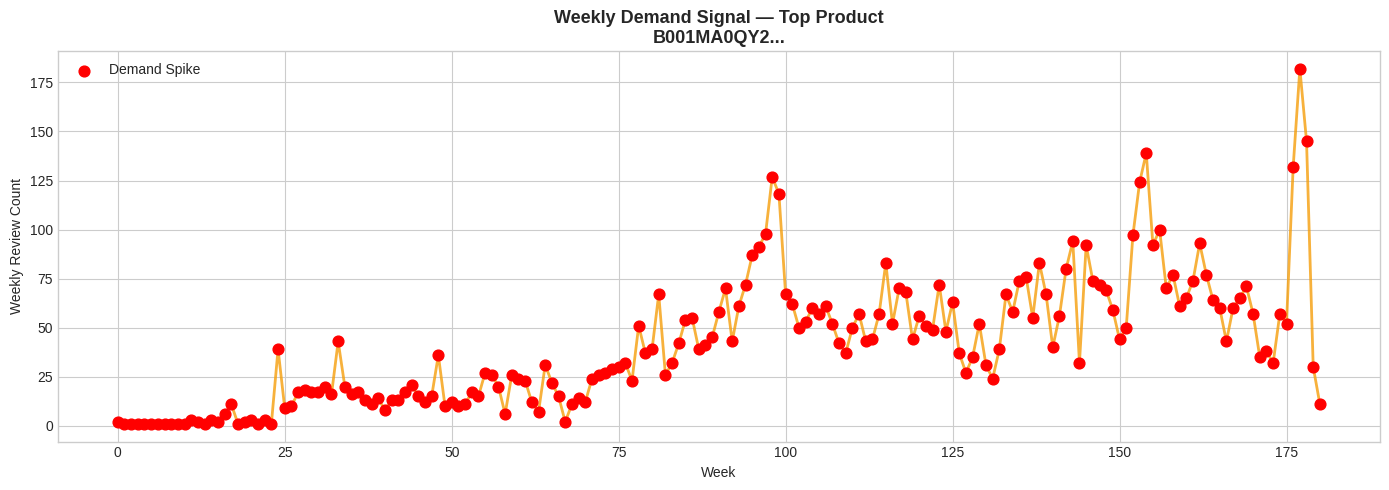

✅ Saved eda_04_demand_signal.png


In [20]:
# Plot demand trend for the most reviewed product
top_product = top_products.iloc[0]['product_id']
product_weekly = weekly_demand[weekly_demand['product_id'] == top_product].sort_values(['year', 'week'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(len(product_weekly)), product_weekly['weekly_reviews'],
        color=GOLD, linewidth=2, alpha=0.8)

# Highlight demand spikes
spikes = product_weekly[product_weekly['demand_spike'] == 1]
ax.scatter(spikes.index - product_weekly.index[0],
           spikes['weekly_reviews'],
           color='red', s=60, zorder=5, label='Demand Spike')

ax.set_title(f'Weekly Demand Signal — Top Product\n{top_product[:20]}...',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Week')
ax.set_ylabel('Weekly Review Count')
ax.legend()

plt.tight_layout()
plt.savefig('eda_04_demand_signal.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved eda_04_demand_signal.png')

## Step 8: TikTok Trend Analysis

In [21]:
# Filter for TikTok data
platform_col = None
for col in df_social.columns:
    if 'platform' in col.lower():
        platform_col = col
        break

if platform_col:
    print(f'Platform distribution:')
    print(df_social[platform_col].value_counts())
    df_tiktok = df_social[df_social[platform_col].str.lower() == 'tiktok'].copy()
    print(f'\n✅ TikTok rows: {len(df_tiktok):,}')
else:
    df_tiktok = df_social.copy()
    print(f'✅ Using full dataset: {len(df_tiktok):,} rows')

Platform distribution:
Platform
YouTube      1324
TikTok       1260
Instagram    1212
Twitter      1204
Name: count, dtype: int64

✅ TikTok rows: 1,260


In [22]:
# TikTok engagement analysis
print('📊 TikTok Dataset Overview:')
print(f'  Rows: {len(df_tiktok):,}')
print(f'  Columns: {df_tiktok.columns.tolist()}')
print(f'\nDescriptive Statistics:')
df_tiktok.describe()

📊 TikTok Dataset Overview:
  Rows: 1,260
  Columns: ['Post_ID', 'Platform', 'Hashtag', 'Content_Type', 'Region', 'Views', 'Likes', 'Shares', 'Comments', 'Engagement_Level']

Descriptive Statistics:


,Views,Likes,Shares,Comments
count,1260.00,1260.00,1260.00,1260.00
mean,2515015.40,244206.72,51468.26,24778.70
std,1440503.57,143816.62,28769.77,14252.81
min,1266.00,1184.00,52.00,91.00
25%,1297480.75,119804.50,27234.75,12188.75
50%,2510894.50,238829.50,53235.50,24629.00
75%,3815422.75,363982.25,76086.75,37183.50
max,4997284.00,499922.00,99978.00,49993.00


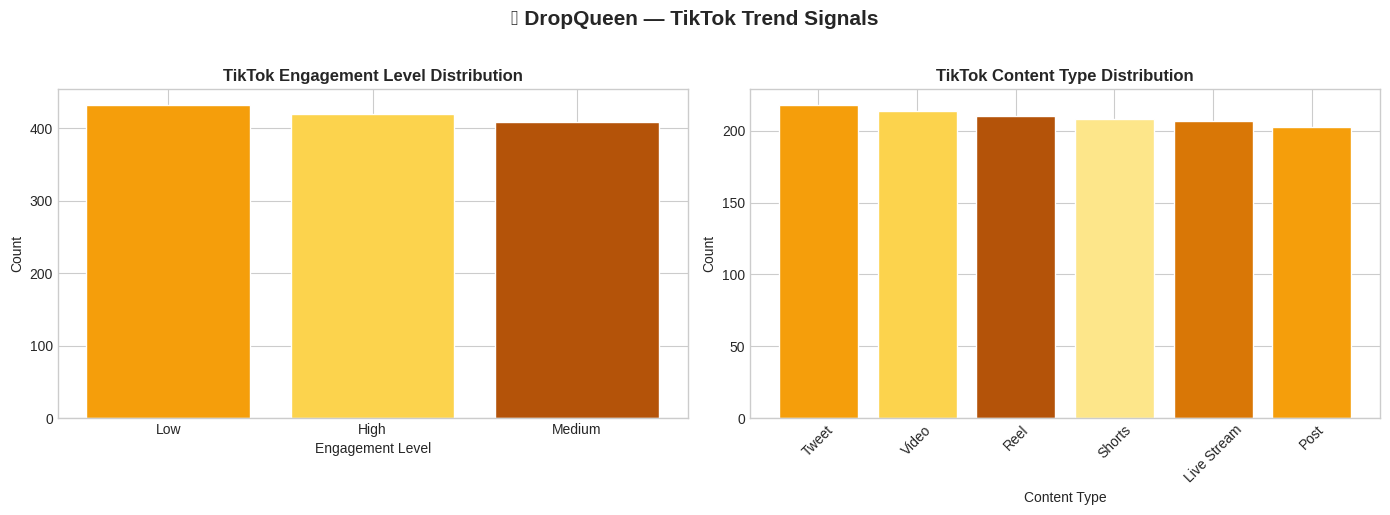

✅ Saved eda_05_tiktok_trends.png


In [23]:
# TikTok engagement distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Engagement level distribution
if 'Engagement_Level' in df_tiktok.columns:
    eng_counts = df_tiktok['Engagement_Level'].value_counts()
    axes[0].bar(eng_counts.index, eng_counts.values,
                color=COLORS[:len(eng_counts)], edgecolor='white')
    axes[0].set_title('TikTok Engagement Level Distribution', fontweight='bold')
    axes[0].set_xlabel('Engagement Level')
    axes[0].set_ylabel('Count')

# Content type distribution
if 'Content_Type' in df_tiktok.columns:
    content_counts = df_tiktok['Content_Type'].value_counts()
    axes[1].bar(content_counts.index, content_counts.values,
                color=COLORS[:len(content_counts)], edgecolor='white')
    axes[1].set_title('TikTok Content Type Distribution', fontweight='bold')
    axes[1].set_xlabel('Content Type')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('👑 DropQueen — TikTok Trend Signals', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_05_tiktok_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved eda_05_tiktok_trends.png')

## Step 9: Save Clean Datasets

In [24]:
# Save Amazon clean dataset
df_amazon.to_csv('dropqueen_amazon_raw.csv', index=False)

# Save weekly demand signal
weekly_demand.to_csv('dropqueen_weekly_demand.csv', index=False)

# Save TikTok dataset
df_tiktok.to_csv('dropqueen_tiktok_raw.csv', index=False)

print('✅ Files saved:')
print('   - dropqueen_amazon_raw.csv')
print('   - dropqueen_weekly_demand.csv')
print('   - dropqueen_tiktok_raw.csv')
print(f'\n📁 Charts created:')
print('   - eda_01_ratings.png')
print('   - eda_02_reviews_over_time.png')
print('   - eda_03_top_products.png')
print('   - eda_04_demand_signal.png')
print('   - eda_05_tiktok_trends.png')

✅ Files saved:
   - dropqueen_amazon_raw.csv
   - dropqueen_weekly_demand.csv
   - dropqueen_tiktok_raw.csv

📁 Charts created:
   - eda_01_ratings.png
   - eda_02_reviews_over_time.png
   - eda_03_top_products.png
   - eda_04_demand_signal.png
   - eda_05_tiktok_trends.png


## Step 10: EDA Summary

In [25]:
print('=' * 60)
print('         👑 DropQueen — Notebook 1 Summary')
print('=' * 60)
print(f'\n📦 AMAZON BEAUTY DATASET:')
print(f'   Total reviews:      {df_amazon.shape[0]:,}')
print(f'   Unique products:    {df_amazon["product_id"].nunique():,}')
print(f'   Unique users:       {df_amazon["user_id"].nunique():,}')
print(f'   Average rating:     {df_amazon["rating"].mean():.2f} ★')
print(f'   Date range:         {df_amazon["year"].min()} — {df_amazon["year"].max()}')
print(f'\n📱 TIKTOK DATASET:')
print(f'   Total posts:        {len(df_tiktok):,}')
print(f'\n📈 DEMAND SIGNAL:')
print(f'   Weekly records:     {len(weekly_demand):,}')
print(f'   Spike rate:         {weekly_demand["demand_spike"].mean()*100:.1f}%')
print(f'   Top product:        {top_products.iloc[0]["product_id"][:20]}...')
print('\n' + '=' * 60)
print('\n✅ Next: Notebook 02 — Data Cleaning & Feature Engineering')

         👑 DropQueen — Notebook 1 Summary

📦 AMAZON BEAUTY DATASET:
   Total reviews:      2,023,070
   Unique products:    249,274
   Unique users:       1,210,271
   Average rating:     4.15 ★
   Date range:         1998 — 2014

📱 TIKTOK DATASET:
   Total posts:        1,260

📈 DEMAND SIGNAL:
   Weekly records:     1,504,357
   Spike rate:         100.0%
   Top product:        B001MA0QY2...


✅ Next: Notebook 02 — Data Cleaning & Feature Engineering
